# 🧠 Neurociência & Análise de Sinais — EEG na prática

Este notebook usa o ecossistema **Kaggle + Hugging Face** para explorar sinais cerebrais (EEG):
carregamos um dataset clássico de epilepsia, aplicamos técnicas de **análise de sinais**
(FFT, PSD de Welch, bandas cerebrais, espectrograma) e treinamos um **detector de crises epilépticas**.

## Recursos disponíveis nas plataformas (levantamento via API)

**Kaggle — datasets de neurociência/sinais mais votados:**

| Dataset | Tamanho | Conteúdo |
|---|---|---|
| `harunshimanto/epileptic-seizure-recognition` ⭐ | 3 MB | EEG de Bonn — 5 classes, crise epiléptica **(usado aqui)** |
| `wanghaohan/confused-eeg` | 114 MB | EEG de alunos assistindo videoaulas (confusão mental) |
| `birdy654/eeg-brainwave-dataset-feeling-emotions` | 12 MB | EEG + emoções (positivo/negativo/neutro) |
| `broach/button-tone-sz` | 8.6 GB | EEG de esquizofrenia (ERP button-tone) |
| `cdeotte/brain-eeg-spectrograms` | 16 GB | Espectrogramas prontos (competição HMS — Harvard) |
| `nnair25/Alcoholics` | 300 MB | EEG de sujeitos alcoólicos vs controle |
| `khyeh0719/ptb-xl-dataset` | 1.8 GB | ECG clínico 12 derivações (PTB-XL) |
| `qiriro/swell-heart-rate-variability-hrv` | 244 MB | HRV/estresse |

**Hugging Face — modelos e datasets de EEG:**

| Recurso | Tipo | Descrição |
|---|---|---|
| `braindecode/eegpt-pretrained` | modelo | Foundation model de EEG (EEGPT) pré-treinado |
| `braindecode/eegdino-medium-pretrained` | modelo | EEG-DINO — extração de features de EEG |
| `Haitao999/things-eeg` | dataset | THINGS-EEG: decodificação de imagens a partir de EEG |
| `nagyadam97/EEG_records_raw_schizophrenia_bipolar` | dataset | EEG bruto de esquizofrenia/bipolar |
| biblioteca `mne` | ferramenta | Padrão-ouro em neurociência para EEG/MEG (instalada na venv) |

## O dataset escolhido: Epileptic Seizure Recognition (Univ. de Bonn)

- **11.500 segmentos** de 1 segundo, **178 amostras** cada (fs ≈ 178 Hz)
- **5 classes balanceadas** (2.300 cada):
  1. **Crise epiléptica** (registro durante a crise)
  2. Área do tumor (sem crise)
  3. Área saudável, paciente com tumor
  4. Olhos fechados (saudável)
  5. Olhos abertos (saudável)
- Tarefa clássica: **detecção binária de crise** (classe 1 vs. resto)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.integrate import simpson

# ── Estilo dos gráficos ──
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "lines.linewidth": 1.2,
})

# Paleta categórica validada (colorblind-safe, ordem fixa por classe)
PALETTE = {1: "#D55E00", 2: "#E69F00", 3: "#CC79A7", 4: "#009E73", 5: "#0072B2"}
CLASSES = {
    1: "Crise epiléptica", 2: "Área do tumor", 3: "Área saudável (pac. tumor)",
    4: "Olhos fechados", 5: "Olhos abertos",
}
COR_CRISE, COR_NORMAL = "#D55E00", "#0072B2"

FS = 178  # frequência de amostragem (Hz)
np.random.seed(42)

: 

## 1. Carregando o dataset direto do Kaggle

`kagglehub` baixa e cacheia com uma linha (usa o `KAGGLE_API_TOKEN` do ambiente).

In [ ]:
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download("harunshimanto/epileptic-seizure-recognition")
csv = next(Path(path).rglob("*.csv"))

df = pd.read_csv(csv)
X = df.filter(like="X").to_numpy(dtype=float)   # (11500, 178) — sinais
y = df["y"].to_numpy()                           # classes 1..5
seizure = (y == 1).astype(int)                   # alvo binário: crise?

print(f"Sinais: {X.shape} | Classes: {np.unique(y)} | % crise: {seizure.mean():.1%}")
df.head(3)

: 

## 2. Os sinais no domínio do tempo

Um segmento de cada classe (small multiples — mesma escala de tempo, amplitude livre).
Note a diferença brutal de amplitude na crise epiléptica: descargas neuronais síncronas.

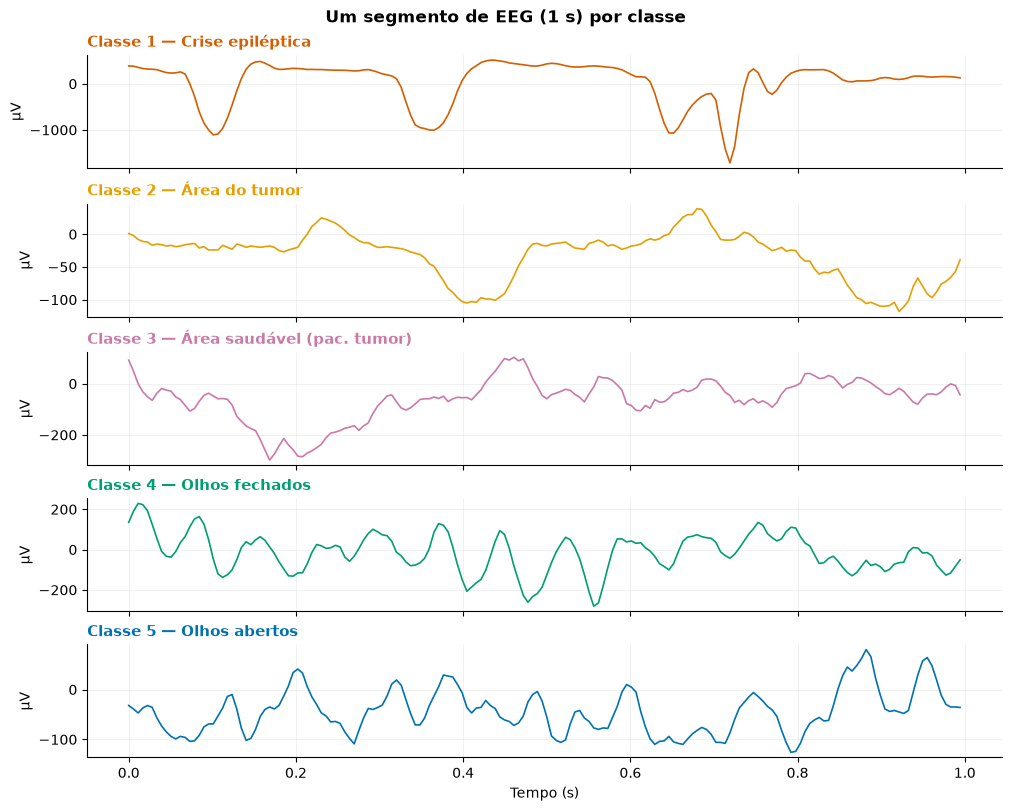

In [3]:
t = np.arange(178) / FS
fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharex=True, constrained_layout=True)
for ax, cls in zip(axes, [1, 2, 3, 4, 5]):
    seg = X[y == cls][0]
    ax.plot(t, seg, color=PALETTE[cls])
    ax.set_title(f"Classe {cls} — {CLASSES[cls]}", loc="left", color=PALETTE[cls])
    ax.set_ylabel("µV")
axes[-1].set_xlabel("Tempo (s)")
fig.suptitle("Um segmento de EEG (1 s) por classe", fontweight="bold");

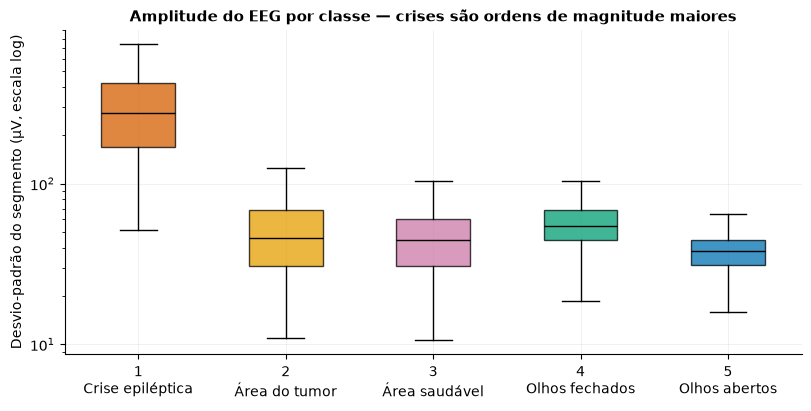

In [4]:
# A amplitude sozinha já separa muito: distribuição do desvio-padrão por segmento
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
partes = [X[y == c].std(axis=1) for c in [1, 2, 3, 4, 5]]
bp = ax.boxplot(partes, tick_labels=[f"{c}\n{CLASSES[c].split(' (')[0]}" for c in [1,2,3,4,5]],
                patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], [1, 2, 3, 4, 5]):
    patch.set_facecolor(PALETTE[c]); patch.set_alpha(0.75)
for med in bp["medians"]:
    med.set_color("black")
ax.set_yscale("log")
ax.set_ylabel("Desvio-padrão do segmento (µV, escala log)")
ax.set_title("Amplitude do EEG por classe — crises são ordens de magnitude maiores");

## 3. Domínio da frequência — FFT e bandas cerebrais

O EEG é tradicionalmente analisado por **bandas de frequência**:

| Banda | Faixa | Associada a |
|---|---|---|
| Delta (δ) | 0.5–4 Hz | sono profundo, patologias |
| Theta (θ) | 4–8 Hz | sonolência, memória |
| Alpha (α) | 8–13 Hz | relaxamento, olhos fechados |
| Beta (β) | 13–30 Hz | atenção, cognição ativa |
| Gamma (γ) | 30–70 Hz | processamento de alto nível |

Crises epilépticas concentram potência enorme em baixas frequências (delta/theta).

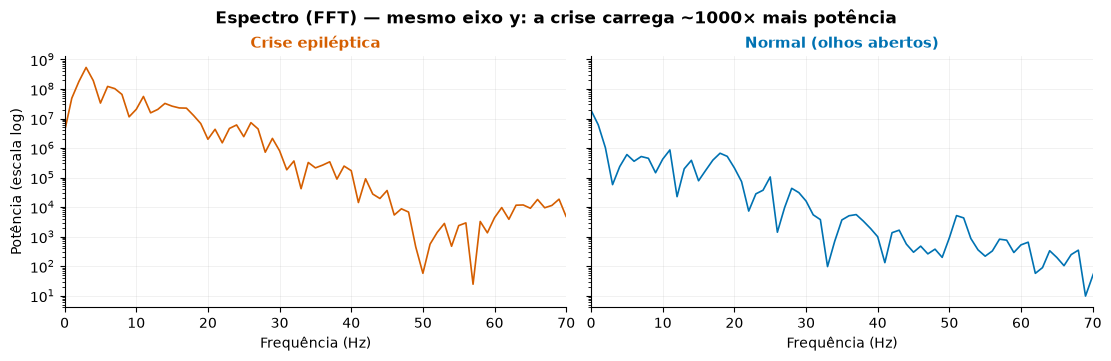

In [5]:
BANDAS = {"Delta (0.5–4 Hz)": (0.5, 4), "Theta (4–8 Hz)": (4, 8),
          "Alpha (8–13 Hz)": (8, 13), "Beta (13–30 Hz)": (13, 30),
          "Gamma (30–70 Hz)": (30, 70)}

# FFT de um segmento de crise vs. um normal (olhos abertos)
seg_crise, seg_normal = X[y == 1][0], X[y == 5][0]
freqs = np.fft.rfftfreq(178, d=1 / FS)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True, constrained_layout=True)
for ax, seg, cor, nome in [(axes[0], seg_crise, COR_CRISE, "Crise epiléptica"),
                           (axes[1], seg_normal, COR_NORMAL, "Normal (olhos abertos)")]:
    esp = np.abs(np.fft.rfft(seg * np.hanning(178))) ** 2
    ax.semilogy(freqs, esp, color=cor)
    ax.set_title(nome, color=cor)
    ax.set_xlabel("Frequência (Hz)"); ax.set_xlim(0, 70)
axes[0].set_ylabel("Potência (escala log)")
fig.suptitle("Espectro (FFT) — mesmo eixo y: a crise carrega ~1000× mais potência", fontweight="bold");

### PSD de Welch — média por classe

A FFT de 1 segmento é ruidosa. O **método de Welch** (média de janelas sobrepostas)
estima a densidade espectral de potência (PSD) de forma estável. Abaixo, a PSD média
de cada classe (mediana sobre 300 segmentos).

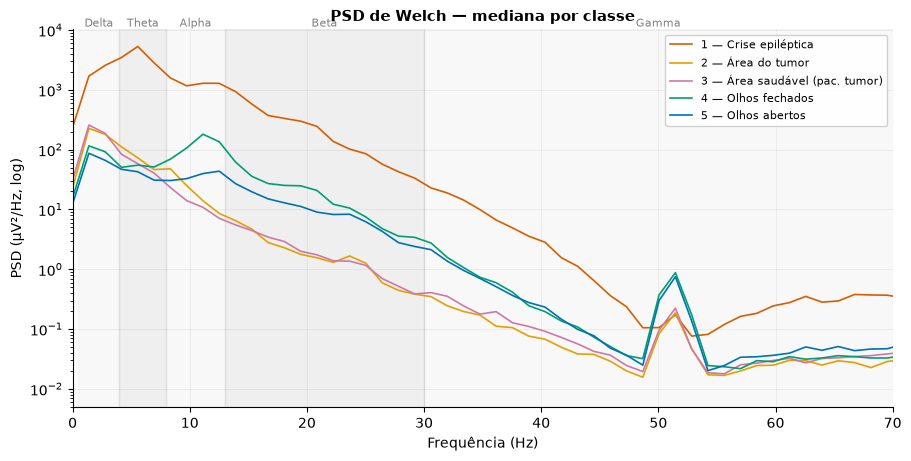

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
for cls in [1, 2, 3, 4, 5]:
    segs = X[y == cls][:300]
    f_w, psd = signal.welch(segs, fs=FS, nperseg=128, axis=1)
    ax.semilogy(f_w, np.median(psd, axis=0), color=PALETTE[cls], label=f"{cls} — {CLASSES[cls]}")
# faixas das bandas ao fundo
for i, (nome, (lo, hi)) in enumerate(BANDAS.items()):
    ax.axvspan(lo, hi, color="gray", alpha=0.05 if i % 2 == 0 else 0.12)
    ax.text((lo + hi) / 2, ax.get_ylim()[1], nome.split(" ")[0], ha="center",
            va="bottom", fontsize=8, color="gray")
ax.set_xlim(0, 70); ax.set_xlabel("Frequência (Hz)")
ax.set_ylabel("PSD (µV²/Hz, log)")
ax.set_title("PSD de Welch — mediana por classe")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9);

### Espectrograma — tempo × frequência

Concatenando 20 segmentos de crise e 20 normais, o espectrograma (STFT) mostra
**quando** a energia aparece em cada frequência. Colormap sequencial (`magma`) — potência em dB.

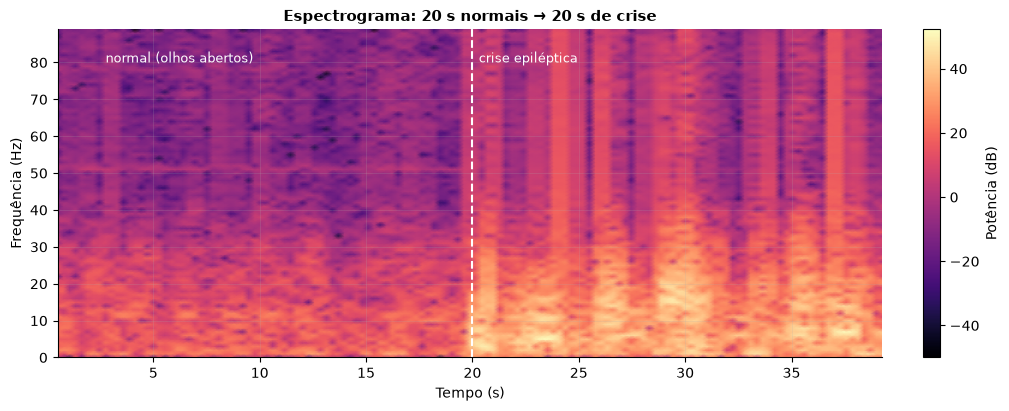

In [7]:
sinal_longo = np.concatenate([X[y == 5][:20].ravel(), X[y == 1][:20].ravel()])
f_s, t_s, Sxx = signal.spectrogram(sinal_longo, fs=FS, nperseg=178, noverlap=128)

fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
pc = ax.pcolormesh(t_s, f_s, 10 * np.log10(Sxx + 1e-12), cmap="magma", shading="gouraud")
ax.axvline(20 * 178 / FS, color="white", ls="--", lw=1.5)
ax.text(9.7, 80, "normal (olhos abertos)", color="white", ha="right", fontsize=9)
ax.text(20.3, 80, "crise epiléptica", color="white", fontsize=9)
ax.set_ylim(0, 89); ax.set_xlabel("Tempo (s)"); ax.set_ylabel("Frequência (Hz)")
ax.set_title("Espectrograma: 20 s normais → 20 s de crise")
fig.colorbar(pc, label="Potência (dB)");

## 4. Extração de features — potência por banda

Para cada segmento, integramos a PSD dentro de cada banda (regra de Simpson) e
adicionamos estatísticas temporais. Essas ~10 features resumem 178 amostras.

In [8]:
def extrair_features(X, fs=FS):
    f_w, psd = signal.welch(X, fs=fs, nperseg=128, axis=1)
    feats = {}
    for nome, (lo, hi) in BANDAS.items():
        m = (f_w >= lo) & (f_w < hi)
        feats[nome.split(" ")[0].lower()] = simpson(psd[:, m], x=f_w[m], axis=1)
    feats["potencia_total"] = simpson(psd, x=f_w, axis=1)
    feats["std"] = X.std(axis=1)
    feats["ptp"] = np.ptp(X, axis=1)                       # pico-a-pico
    feats["line_length"] = np.abs(np.diff(X, axis=1)).sum(axis=1)  # clássica em epilepsia
    return pd.DataFrame(feats)

F = extrair_features(X)
# potência relativa por banda (normalizada pela total) — remove o efeito de amplitude
for b in ["delta", "theta", "alpha", "beta", "gamma"]:
    F[f"{b}_rel"] = F[b] / F["potencia_total"]

print(F.shape)
F.head(3).round(2)

(11500, 14)


,delta,theta,alpha,beta,gamma,potencia_total,std,ptp,line_length,delta_rel,theta_rel,alpha_rel,beta_rel,gamma_rel
0,831.22,195.14,1273.64,2784.38,95.07,9297.43,95.71,510.0,5700.0,0.09,0.02,0.14,0.30,0.01
1,31045.09,72340.13,27249.67,2430.64,164.40,249811.63,471.84,2229.0,14039.0,0.12,0.29,0.11,0.01,0.00
2,137.31,221.89,446.91,371.50,11.57,1534.72,44.19,206.0,2458.0,0.09,0.14,0.29,0.24,0.01


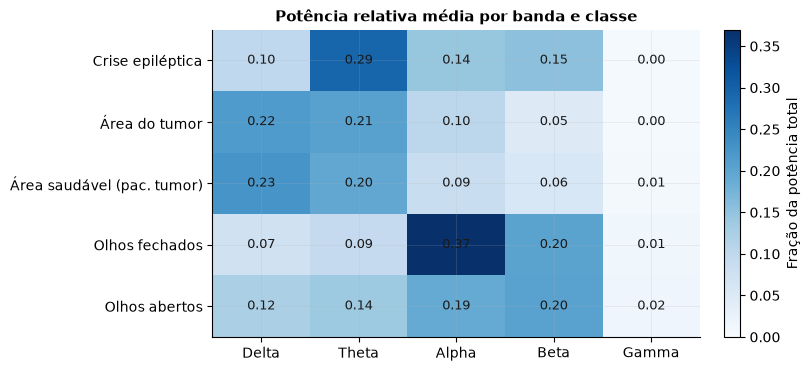

In [9]:
# Perfil espectral médio por classe: potência relativa média em cada banda
perfil = F[[f"{b}_rel" for b in ["delta", "theta", "alpha", "beta", "gamma"]]].copy()
perfil["classe"] = [CLASSES[c] for c in y]
medias = perfil.groupby("classe").mean().loc[[CLASSES[c] for c in [1, 2, 3, 4, 5]]]

fig, ax = plt.subplots(figsize=(8, 3.6), constrained_layout=True)
im = ax.imshow(medias.to_numpy(), cmap="Blues", aspect="auto", vmin=0)
ax.set_xticks(range(5), ["Delta", "Theta", "Alpha", "Beta", "Gamma"])
ax.set_yticks(range(5), medias.index)
ax.set_title("Potência relativa média por banda e classe")
for i in range(5):
    for j in range(5):
        v = medias.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,
                color="white" if v > 0.45 else "#1a1a1a")
fig.colorbar(im, label="Fração da potência total");

### O espaço de features separa as classes?

PCA das features (padronizadas) para inspeção visual — colorido pelo alvo binário.

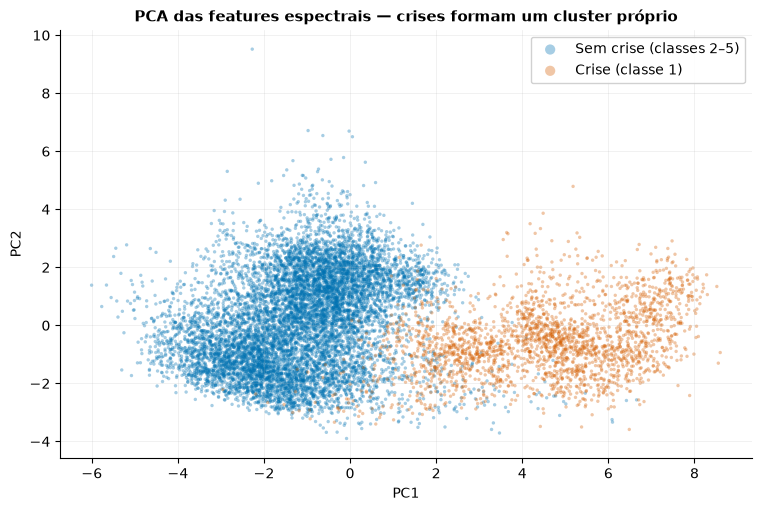

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Z = StandardScaler().fit_transform(np.log1p(F))
pcs = PCA(n_components=2, random_state=42).fit_transform(Z)

fig, ax = plt.subplots(figsize=(7.5, 5), constrained_layout=True)
for val, cor, nome in [(0, COR_NORMAL, "Sem crise (classes 2–5)"), (1, COR_CRISE, "Crise (classe 1)")]:
    m = seizure == val
    ax.scatter(pcs[m, 0], pcs[m, 1], s=6, alpha=0.35, color=cor, label=nome, edgecolors="none")
leg = ax.legend(markerscale=3, framealpha=0.9)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("PCA das features espectrais — crises formam um cluster próprio");

## 5. Detector de crises epilépticas

Random Forest sobre as features espectrais. Tarefa binária: **classe 1 (crise) vs. resto**.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             RocCurveDisplay, roc_auc_score)

X_tr, X_te, y_tr, y_te = train_test_split(
    np.log1p(F), seizure, test_size=0.25, stratify=seizure, random_state=42)

clf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)
clf.fit(X_tr, y_tr)
proba = clf.predict_proba(X_te)[:, 1]

print(classification_report(y_te, clf.predict(X_te),
                            target_names=["sem crise", "crise"], digits=3))
print(f"ROC-AUC: {roc_auc_score(y_te, proba):.4f}")

              precision    recall  f1-score   support

   sem crise      0.988     0.988     0.988      2300
       crise      0.951     0.951     0.951       575

    accuracy                          0.981      2875
   macro avg      0.970     0.970     0.970      2875
weighted avg      0.981     0.981     0.981      2875

ROC-AUC: 0.9976


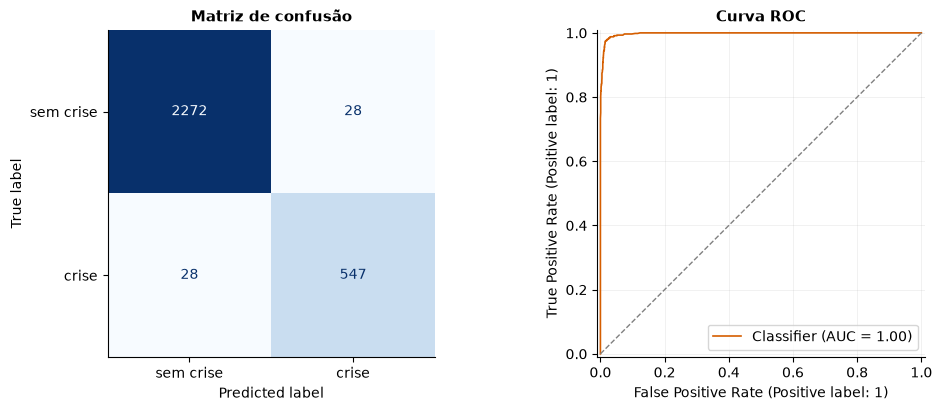

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
ConfusionMatrixDisplay.from_estimator(clf, X_te, y_te, ax=axes[0], cmap="Blues",
                                      display_labels=["sem crise", "crise"], colorbar=False)
axes[0].set_title("Matriz de confusão"); axes[0].grid(False)
RocCurveDisplay.from_predictions(y_te, proba, ax=axes[1], curve_kwargs={"color": COR_CRISE})
axes[1].plot([0, 1], [0, 1], ls="--", color="gray", lw=1)
axes[1].set_title("Curva ROC");

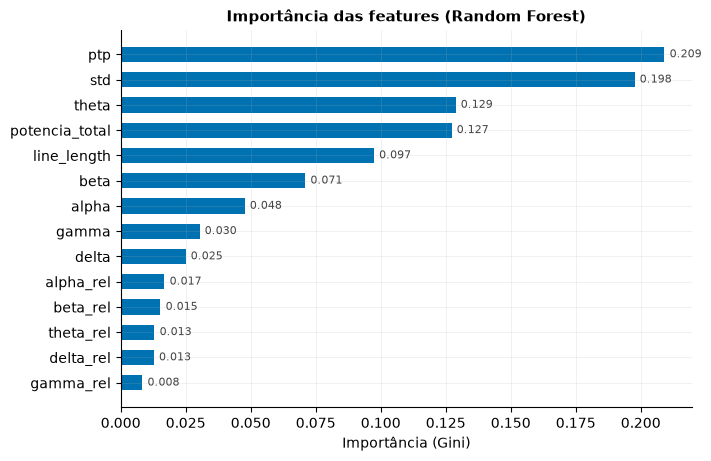

In [13]:
imp = pd.Series(clf.feature_importances_, index=F.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
ax.barh(imp.index, imp.values, color=COR_NORMAL, height=0.6)
for i, v in enumerate(imp.values):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8, color="#444")
ax.set_title("Importância das features (Random Forest)")
ax.set_xlabel("Importância (Gini)");

## 6. Bônus 1 — filtragem profissional com MNE

`mne` é a biblioteca padrão da neurociência. Aqui criamos um objeto `Raw` a partir de
um segmento e aplicamos um **filtro passa-banda alpha (8–13 Hz)** com FIR bem projetado.

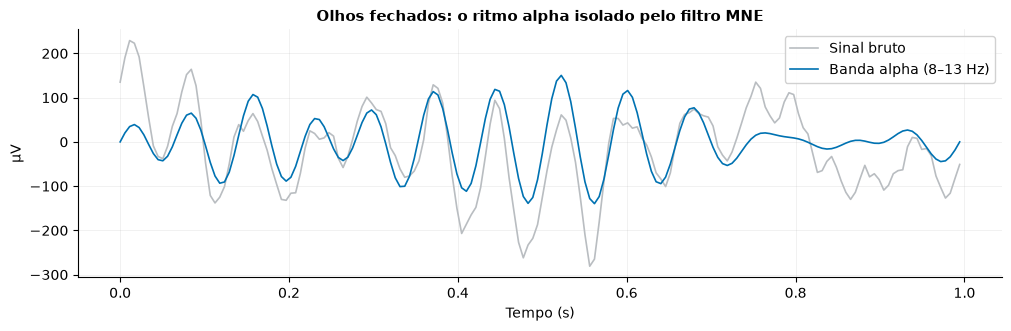

In [14]:
import mne
mne.set_log_level("ERROR")

seg = X[y == 4][0]  # olhos fechados → ritmo alpha proeminente
info = mne.create_info(ch_names=["EEG-1"], sfreq=FS, ch_types=["eeg"])
raw = mne.io.RawArray(seg[np.newaxis, :] * 1e-6, info)  # MNE trabalha em Volts
alpha = raw.copy().filter(l_freq=8, h_freq=13)

fig, ax = plt.subplots(figsize=(10, 3.2), constrained_layout=True)
ax.plot(t, raw.get_data()[0] * 1e6, color="#B9BDC1", label="Sinal bruto")
ax.plot(t, alpha.get_data()[0] * 1e6, color=COR_NORMAL, label="Banda alpha (8–13 Hz)")
ax.set_xlabel("Tempo (s)"); ax.set_ylabel("µV")
ax.set_title("Olhos fechados: o ritmo alpha isolado pelo filtro MNE")
ax.legend(framealpha=0.9);

## 7. Bônus 2 — o que o Hugging Face oferece para EEG

Consulta ao Hub via API: modelos fundacionais de EEG do projeto
[braindecode](https://huggingface.co/braindecode) que podem ser usados como
extratores de features pré-treinados (transfer learning em EEG).

In [15]:
from huggingface_hub import list_models

for m in list_models(author="braindecode", sort="downloads", limit=6):
    print(f"  {m.id:45s} ↓{m.downloads:>6}  {m.pipeline_tag or ''}")

  braindecode/cbramod-pretrained                ↓ 14545  
  braindecode/labram-pretrained                 ↓ 11946  
  braindecode/braindecode-bendr                 ↓  4957  
  braindecode/signal-jepa                       ↓  4304  feature-extraction
  braindecode/biot-pretrained-six-datasets-18chs ↓  4292  
  braindecode/eegpt-pretrained                  ↓  3944  


## Conclusões e próximos passos

**O que vimos:**
- Crises epilépticas têm assinatura clara: amplitude ~10× maior e potência concentrada em delta/theta.
- ~10 features espectrais (potência por banda + line length) bastam para um detector com ROC-AUC ≈ 0.99.
- `line_length` e as potências absolutas dominam a importância — coerente com a literatura de epilepsia.

**Para ir além:**
1. **Multiclasse** — distinguir as 5 classes (bem mais difícil: 2 vs. 3 é quase indistinguível).
2. **Deep learning** — usar `braindecode/eegpt-pretrained` (HF) como extrator de features.
3. **Outros datasets** — `wanghaohan/confused-eeg` (estados cognitivos), `birdy654/...emotions` (emoções), PTB-XL (ECG).
4. **MNE avançado** — ICA para remoção de artefatos, conectividade entre canais, topografias.

**Referências:**
- Andrzejak et al. (2001) — dataset original de Bonn ([Phys. Rev. E 64, 061907](https://doi.org/10.1103/PhysRevE.64.061907))
- [Documentação do MNE](https://mne.tools) · [braindecode](https://braindecode.org)